In [18]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt


# Problem 1

$$\min e^{x_1 - 1} + e^{-x_1 + 1} + e^{x_2-2} + e^{-x_2 +2 } + e^{-x_3 + 3} + (x_1 - 2x_2 +5x_3)^4$$

In [49]:
# Write a code in CVX to find the global minimum x*

x1 = cp.Variable()
x2 = cp.Variable()
x3 = cp.Variable()

objective = cp.Minimize(
    cp.exp(x1-1) + cp.exp(-x1+1) +
    cp.exp(x2-2) + cp.exp(-x2+2) +
    cp.exp(x3-3) + cp.exp(-x3+3) +
    cp.power((x1 - 2*x2 + 5*x3), 4)
)

problem = cp.Problem(objective)
problem.solve()

x1_cp = x1.value
x2_cp = x2.value
x3_cp = x3.value

print(f"CVXPY Solution: x1 = {x1_cp}, x2 = {x2_cp}, x3 = {x3_cp}")

CVXPY Solution: x1 = 0.4573801355825401, x2 = 2.976508302346172, x3 = 1.2307154858979108


In [96]:
# Then, write a code that implements the Gradient method with your choice of the backtracking parameters. 

x1 = 1
x2 = 1
x3 = 1

arr_g = []
arr_g.append([x1, x2, x3])


def f(x):
    x1, x2, x3 = x
    return (np.exp(x1-1) + np.exp(-x1+1) + np.exp(x2-2) + np.exp(-x2+2) + np.exp(x3-3) + np.exp(-x3+3) + (x1 - 2*x2 + 5*x3)**4)


def calc_gradient(x):
    x1, x2, x3 = x

    dx1 = np.exp(x1-1) - np.exp(-x1+1) + 4 * (x1 - 2*x2 + 5*x3)**3 * 1
    dx2 = np.exp(x2-2) - np.exp(-x2+2) + 4 * (x1 - 2*x2 + 5*x3)**3 * (-2)
    dx3 = np.exp(x3-3) - np.exp(-x3+3) + 4 * (x1 - 2*x2 + 5*x3)**3 * (5)
    return np.array([dx1, dx2, dx3])


def step_size():
    # backtracking line search 
    alpha = 0.05  # Step size reduction factor
    beta = 0.1  # Inital t

    while f(arr_g[-1] - beta * calc_gradient(arr_g[-1])) >= f(arr_g[-1]):
        beta *= alpha

    return beta


for i in range(51):
    gradient = calc_gradient(arr_g[-1])
    t = step_size()
    x_new = arr_g[-1] - t * gradient
    arr_g.append(x_new)

xstar = arr_g[-1]
print(f"Gradient Descent Solution: x1 = {xstar[0]}, x2 = {xstar[1]}, x3 = {xstar[2]}")

Gradient Descent Solution: x1 = 0.4566138962977194, x2 = 2.972826937170818, x3 = 1.2294275351541832


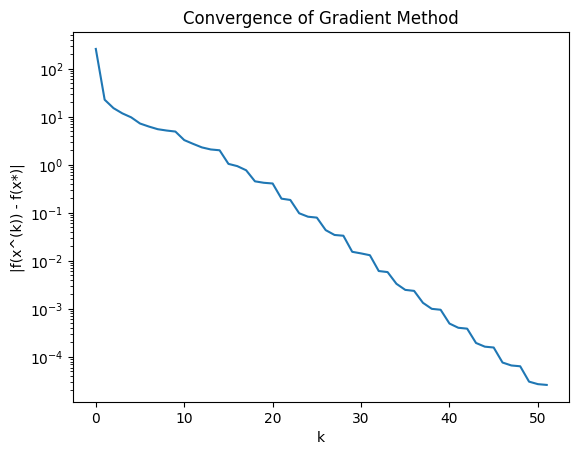

In [97]:
# Draw |f(x(k)) − f(x∗)| verses k for k = 0, 1, 2, . . . , 50 on alog-linear plot. 
# Show the trajectory of the points x(0), x(1), ..., x(50) in the 3-dimensional (x1, x2, x3) plane.

f_vals = np.array([f(x) for x in arr_g])

x_star = np.array([x1_cp, x2_cp, x3_cp])
f_star = f(x_star)

errors = np.abs(f_vals - f_star)
k = np.arange(len(arr_g))

plt.semilogy(k, errors)

plt.xlabel("k")
plt.ylabel("|f(x^(k)) - f(x*)|")
plt.title("Convergence of Gradient Method")

plt.show()

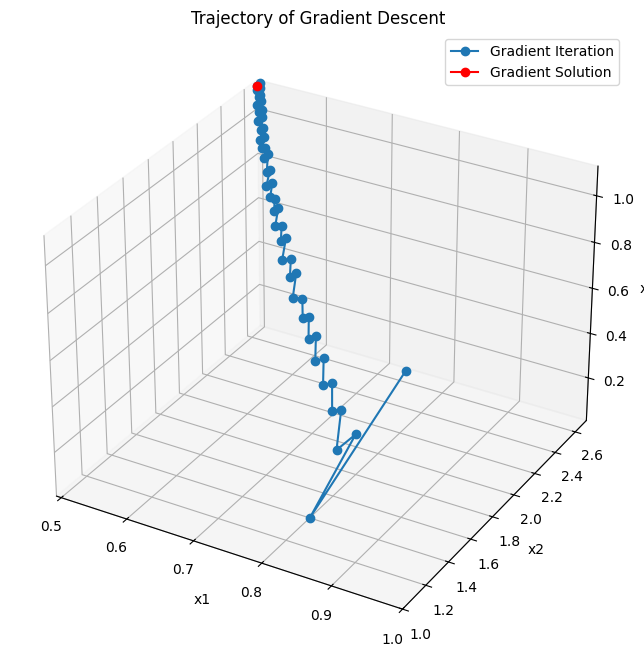

In [91]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, projection="3d")

arr_g = np.array(arr_g)

ax.plot(arr_g[:,0], arr_g[:,1], arr_g[:,2], marker="o", label = "Gradient Iteration")

ax.plot(*xstar, marker="o", color="red", label = "Gradient Solution")

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Trajectory of Gradient Descent")

ax.set_xlim(min(arr_g[:,0]), max(arr_g[:,0]) )
ax.set_ylim(min(arr_g[:,1]), max(arr_g[:,1]) )
ax.set_zlim(min(arr_g[:,2]), max(arr_g[:,2]) )
ax.legend()

plt.show()

\newpage

# Problem 2
Redo the previous problem with Newton’s method.

In [ ]:
x_0 = [1,1,1]
arr_n = np.array(x_0)

alpha = 0.5
beta = 0.1

for i in range(50):
    hessian = np.diag([
        np.exp(x[0]-1) + np.exp(-x[0]+1),
        np.exp(x[1]-2) + np.exp(-x[1]+2),
        np.exp(x[2]-3) + np.exp(-x[2]+3)
    ])
    gradient = np.array([
        np.exp(x[0]-1) - np.exp(-x[0]+1) + 1,
        np.exp(x[1]-2) - np.exp(-x[1]+2) - 2,
        np.exp(x[2]-3) - np.exp(-x[2]+3) + 5
    ])
    delta = np.linalg.solve(hessian, gradient)
    
    t = 1
    # backtracking line search
    while f(x - t * delta) > f(x) - alpha * t * gradient @ delta:
        t *= beta  # shrink step size

    # update x after line search
    x = x - t * delta
    arr_n.append(x.copy())

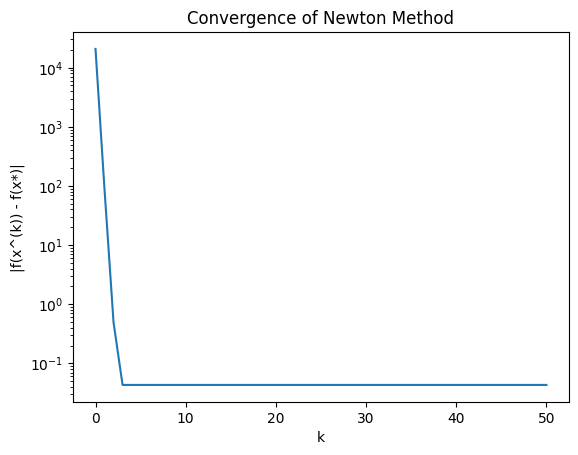

In [56]:
f_vals = np.array([f(x) for x in arr_n])

x_star = np.array([x1_cp, x2_cp, x3_cp])
f_star = f(x_star)

errors = np.abs(f_vals - f_star)
k = np.arange(len(arr_n))

plt.semilogy(k, errors)

plt.xlabel("k")
plt.ylabel("|f(x^(k)) - f(x*)|")
plt.title("Convergence of Newton Method")

plt.show()

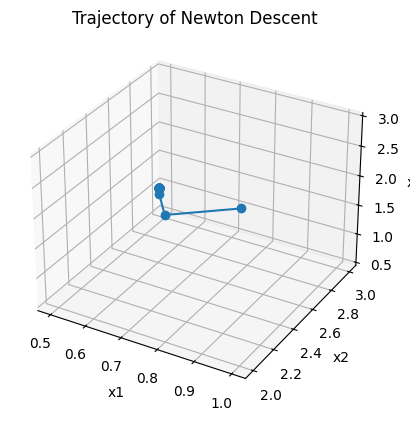

In [57]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

arr_n = np.array(arr_n)

ax.plot(arr_n[:,0], arr_n[:,1], arr_n[:,2], marker="o")

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Trajectory of Newton Descent")

plt.show()

In [ ]:
# 3 CVX
n = 2000
eps = 1e-4

x = cp.Variable(n)

term1 = -cp.sum(cp.log(1 - cp.square(x)))
term2 = -cp.sum(cp.log(4 + A @ x))

objective = cp.Minimize(term1 + term2)

constraints = [
    cp.abs(x) <= 1 - eps,
    4 + A @ x >= eps
]

In [27]:
# 3 CVX
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCS, eps=1e-3, max_iters=20, verbose=False)

x_star = x.value

print("Optimal value:", problem.value)
print("First 10 entries of x*:", x_star[:10])

KeyboardInterrupt: 

In [ ]:
# 3 Newton's 

n = 2000

A = np.random.randn(n, n)

x = np.zeros(n)

alpha = 0.25
beta = 0.5

def f(x):
    term1 = -np.sum(np.log(1 - x**2))
    term2 = -np.sum(np.log(4 + A @ x))
    return term1 + term2

def grad(x):
    g1 = 2*x/(1 - x**2)
    g2 = A.T @ (1/(4 + A @ x))
    return g1 - g2

def hess(x):
    diag1 = 2*(1 + x**2)/(1 - x**2)**2
    H1 = np.diag(diag1)

    d = 1/(4 + A @ x)**2
    H2 = A.T @ (d[:,None] * A)

    return H1 + H2

max_iter = 100

x_vals = [x.copy()]
f_vals = [f(x)]

for k in range(max_iter):

    g = grad(x)
    H = hess(x)

    delta = -np.linalg.solve(H, g)

    t = 1

    while f(x + t*delta) > f(x) + alpha*t*(g @ delta):
        t *= beta

    x = x + t*delta

    x_vals.append(x.copy())
    f_vals.append(f(x))

In [ ]:
# plot
f_star = problem.value

errors = np.abs(np.array(f_vals) - f_star)

for i in range(100):
    hessian = [[np.exp(x1-1) + np.exp(-x1+1), 0, 0], 
           [0, np.exp(x2-2) + np.exp(-x2+2), 0], 
           [0, 0, np.exp(x3-3) + np.exp(-x3+3)]]
    gradient = [x1 - t * (np.exp(x1-1) - np.exp(-x1+1) + 1), 
                x2 - t * (np.exp(x2-2) - np.exp(-x2+2) - 2), 
                x3 - t * (np.exp(x3-3) - np.exp(-x3+3) + 5)]
    x_new = [x1, x2, x3] - t * (np.linalg.inv(hessian) @ gradient)
    arr_n.append(x_new)
    x1, x2, x3 = x_new[0], x_new[1], x_new[2]